# Can you really get crash insurance for free? 🪢
### The "costless collar" — a real trade that's real about the crash protection and quiet about the price you pay

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Free_protection%3F: Busted](https://img.shields.io/badge/Free_protection%3F-Busted-8b949e?style=flat-square)

An options desk pitches you this: own the S&P 500. Buy a put that floors your losses at 5%. Sell a call — at a strike chosen so its premium exactly pays for the put. Net cost today: **zero**. You've just bought crash insurance and someone else paid for it.

That's the pitch. It has a real name (a *collar*), a real published index (the CBOE's own 95-110 Collar Index), and it is not a scam — the mechanism is real. The question is whether "free" survives contact with what actually happens over the following month, year, and decade.

> 📓 **Plain-language layer.** Want the Black-Scholes cap solver, the *t*-stats and the cost-sensitivity sweep? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **Method note.** There's no historical SPY option chain on yfinance, so we build a stylized monthly collar priced off Black-Scholes and realized volatility — every approximation is named, not hidden. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from costless_collar import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    DAILY = data.load_real()
    MF = data.month_frame(DAILY)
    CAPS = st.collar_caps(MF["vol_in"], put_otm=data.PUT_OTM, r=data.RF_ANNUAL, T=data.OPTION_T)
    MF = MF.join(CAPS.rename("cap_pct"))
    COLL5 = st.collar_returns(MF["spy_ret"], MF["cap_pct"], put_otm=data.PUT_OTM, cost_bps=5.0)
    DF = pd.concat([MF, COLL5], axis=1)
else:
    DAILY = MF = CAPS = DF = None
print("real cache present:", HAVE_REAL, "| months on tape:", (0 if DF is None else len(DF)))

# frozen headline numbers (mirror of docs/results.md)
R = {'spy_rows': 8410, 'spy_start': '1993-02-01', 'spy_end': '2026-06-30', 'fp_spy': '44daf42aa058', 'n_months': 397, 'm_start': '1993-06-30', 'm_end': '2026-06-30', 'cap_mean': 5.93, 'cap_min': 5.81, 'cap_max': 6.67, 'floor_pct': -5.0, 'vol_min': 5.6, 'vol_max': 70.7, 'vol_mean': 16.4, 'breakeven_bps': 3.84, 'cost_table': {5.0: (-2.3, -0.34, -0.33, 31.39), 10.0: (-12.3, -1.79, -1.76, 21.17), 15.0: (-22.3, -3.25, -3.2, 14.27), 20.0: (-32.3, -4.7, -4.63, 9.62)}, 'floor_n': 37, 'floor_cushion': 2.68, 'floor_t': 6.39, 'floor_worst_spy': -16.52, 'floor_worst_collar': -5.1, 'cap_n': 42, 'cap_share': 10.6, 'cap_cost': -1.83, 'cap_t': -7.67, 'cap_best_spy': 12.7, 'tw_spy': 29.95, 'tw_collar': 31.39, 'sharpe_spy': 0.57, 'sharpe_collar': 0.69, 'dd_spy': -50.8, 'dd_collar': -33.6, 'gfc_spy': -50.8, 'gfc_collar': -31.9, 'gfc_cut': 18.9, 'covid_spy': -19.4, 'covid_collar': -10.1, 'covid_cut': 9.4, 'exwin_n': 375, 'exwin_diff_bps': -10.8, 'exwin_t': -1.95, 'exwin_nwt': -2.1, 'exwin_tw_spy': 61.05, 'exwin_tw_collar': 44.83, 'exwin_sh_spy': 0.81, 'exwin_sh_collar': 0.86, 'syn_null_fires': 0, 'syn_planted_t': -5.08, 'syn_planted_sd': 1.03, 'syn_planted_fire': 20}


real cache present: True | months on tape: 397


## The answer first

| Question | Answer |
|---|---|
| Does the floor actually protect you? | **Yes — a lot, in the crashes that matter.** The 2008 drawdown gets cut from **-51%** to **-32%**; 2020 from **-19%** to **-10%**. |
| Does the cap actually cost you? | **Yes — reliably.** In the roughly 1-in-10 months SPY beat that month's cap, you gave up **1.83 points on average** — once as much as 13% in a single month. |
| So does it net out ahead? | **Only because 2008 and 2020 happened to be in the sample.** Strip out just those two windows — leave everything else (including the dot-com crash) in — and the collar **loses to buy & hold, statistically for real**. |
| Is it really "free"? | **No.** You always pay in the cap, every time it binds, crash or no crash. "Costless" describes the day you put the trade on, not the trade. |

> Real insurance. Real premium. The premium is just paid in upside, not dollars.

## 1 · The claim

> *"Buy a put 5% below the market to floor your losses. Sell a call at a strike chosen so its premium exactly covers what you paid for the put. Net premium: zero. You've hedged the crash and it didn't cost you a thing."*

It's a real, tradable structure — the CBOE even publishes an index for a version of it (the 95-110 Collar Index). The appeal is obvious: nobody likes paying for insurance, and this pitch says you don't have to.

## 2 · So what?

If a collar really were "free" downside protection, every long-only investor should run one, always — you'd cut your worst drawdowns to a known floor and pay nothing for it. That would be a genuine free lunch, and free lunches in markets are the thing this whole desk exists to hunt down and, usually, debunk.

So: does the floor really protect you? Does the cap really cost you? And when you add it all up over a real 33-year stretch of the market — crashes included — who actually comes out ahead?

## 3 · How would we even know?

- **Build the collar, honestly.** No live option chain exists in our data, so each month we price a 5%-OTM put and solve for the call strike that makes its premium match (Black-Scholes, off trailing realized volatility) — that's our model's "costless."
- **Clip SPY's real monthly return** to [floor, that month's cap], charge a modest cost for rolling both legs, and compare to just holding SPY.
- **Split the sample two ways**: months where the floor actually bound (crash months) and months where the cap actually bound (melt-up months) — is either effect statistically real, or just noise?
- **The falsification test:** strip the two crash windows the pitch itself is selling (2008, 2020) out of the sample. If the "free lunch" survives without them, it's structural. If it vanishes, it was never free — it was a bet on crashes happening, and it paid off because two did.

## 4 · The teardown — let's actually look

**First: does the floor protect, and does the cap cost?**

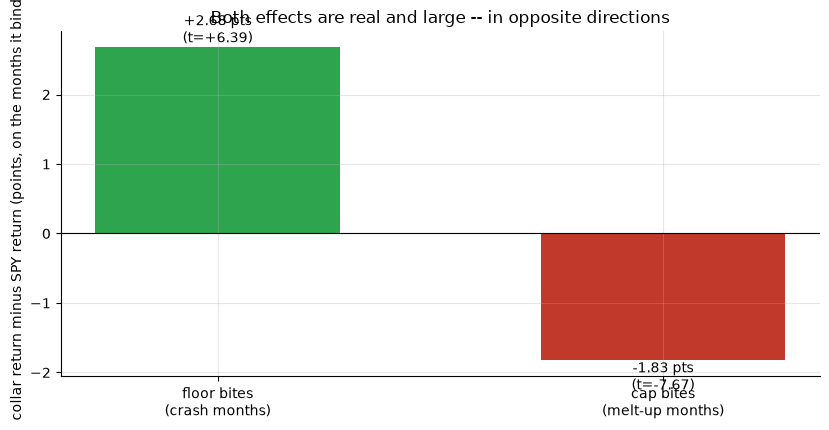

floor cushion +2.68 pts (t=+6.39)   cap cost -1.83 pts (t=-7.67)


In [2]:
if HAVE_REAL:
    cf = st.crash_floor_effect(DF, thresh=-data.PUT_OTM)
    cc = st.cap_cost_effect(DF)
    fc, ft = cf['mean_cushion_pts'], cf['t_plain']
    cco, cct = cc['mean_cost_pts'], cc['t_plain']
else:
    fc, ft = R['floor_cushion'], R['floor_t']
    cco, cct = R['cap_cost'], R['cap_t']
fig, ax = plt.subplots(figsize=(8.4, 4.4))
ax.bar(['floor bites\n(crash months)', 'cap bites\n(melt-up months)'], [fc, cco],
       color=[GREEN, RED], width=.55)
for i,(v,t_) in enumerate([(fc,ft),(cco,cct)]):
    ax.annotate(f'{v:+.2f} pts\n(t={t_:+.2f})',(i,v),ha='center',
        va='bottom' if v>0 else 'top')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('collar return minus SPY return (points, on the months it binds)')
ax.set_title('Both effects are real and large -- in opposite directions')
plt.tight_layout(); plt.show()
print(f'floor cushion {fc:+.2f} pts (t={ft:+.2f})   cap cost {cco:+.2f} pts (t={cct:+.2f})')

Both bars clear the bar for "statistically real" by a wide margin (**|t| ≥ 6** either way). The floor cushioned the worst SPY month from **-16.5%** to **-5.1%**. The cap gave up as much as **12.7%** in a single strong month. Neither of these is folklore — they're mechanical facts about a floor-and-cap structure.

**Now the crashes the whole trade is sold on:**

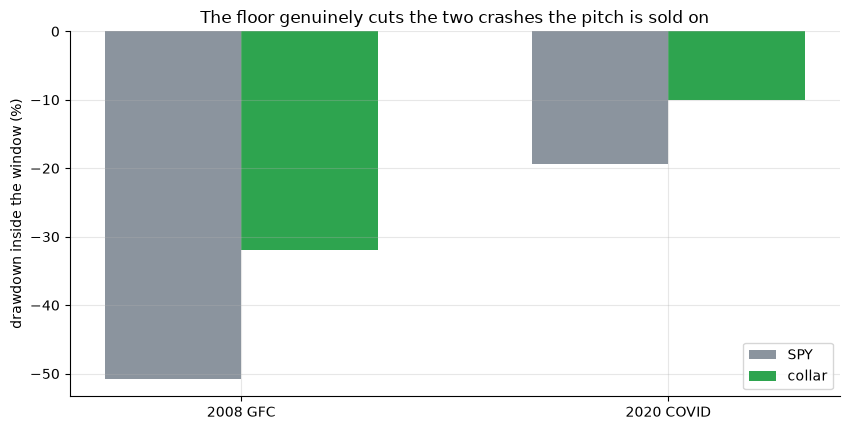

2008: SPY -50.8%  collar -31.9%
2020: SPY -19.4%  collar -10.1%


In [3]:
if HAVE_REAL:
    d_gfc_spy = st.window_drawdown(DF['spy_ret'], *data.GFC_WINDOW)
    d_gfc_coll = st.window_drawdown(DF['collar_ret'], *data.GFC_WINDOW)
    d_cov_spy = st.window_drawdown(DF['spy_ret'], *data.COVID_WINDOW)
    d_cov_coll = st.window_drawdown(DF['collar_ret'], *data.COVID_WINDOW)
else:
    d_gfc_spy, d_gfc_coll = R['gfc_spy']/100, R['gfc_collar']/100
    d_cov_spy, d_cov_coll = R['covid_spy']/100, R['covid_collar']/100
fig, ax = plt.subplots(figsize=(8.6, 4.4))
x = np.arange(2); w = .32
ax.bar(x-w/2, [d_gfc_spy*100, d_cov_spy*100], width=w, color=GREY, label='SPY')
ax.bar(x+w/2, [d_gfc_coll*100, d_cov_coll*100], width=w, color=GREEN, label='collar')
ax.set_xticks(x); ax.set_xticklabels(['2008 GFC', '2020 COVID'])
ax.set_ylabel('drawdown inside the window (%)')
ax.set_title('The floor genuinely cuts the two crashes the pitch is sold on')
ax.legend(); plt.tight_layout(); plt.show()
print(f'2008: SPY {d_gfc_spy*100:.1f}%  collar {d_gfc_coll*100:.1f}%')
print(f'2020: SPY {d_cov_spy*100:.1f}%  collar {d_cov_coll*100:.1f}%')

This part of the pitch is simply true: real, substantial drawdown protection in both headline crashes. If the story stopped here, it'd be a clean win.

**But now the honest test — take the two crashes back out.** Not all of history, just the two specific windows the pitch itself invokes:

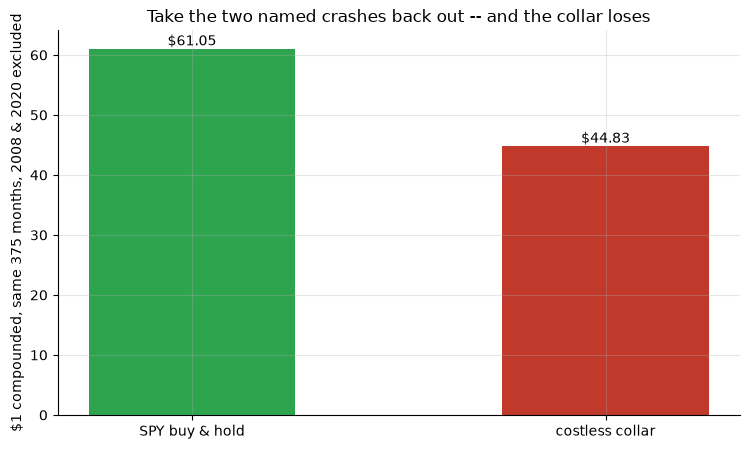

ex-crash terminal wealth: SPY $61.05  vs  collar $44.83


In [4]:
if HAVE_REAL:
    sub = st.exclude_windows(DF, [data.GFC_WINDOW, data.COVID_WINDOW])
    tw_spy = st.terminal_wealth(sub['spy_ret'])
    tw_coll = st.terminal_wealth(sub['collar_ret'])
else:
    tw_spy, tw_coll = R['exwin_tw_spy'], R['exwin_tw_collar']
fig, ax = plt.subplots(figsize=(7.6, 4.6))
ax.bar(['SPY buy & hold', 'costless collar'], [tw_spy, tw_coll],
       color=[GREEN, RED], width=.5)
for i,v in enumerate([tw_spy, tw_coll]): ax.annotate(f'${v:,.2f}',(i,v),ha='center',va='bottom')
ax.set_ylabel('$1 compounded, same 375 months, 2008 & 2020 excluded')
ax.set_title('Take the two named crashes back out -- and the collar loses')
plt.tight_layout(); plt.show()
print(f'ex-crash terminal wealth: SPY ${tw_spy:,.2f}  vs  collar ${tw_coll:,.2f}')

$1 in SPY becomes **$61.05**; the same $1 run through the collar becomes **$44.83** — over the *identical* 375 months, with the two headline crashes removed (the 2000–2002 dot-com bear market is deliberately left in, so this isn't rigged in SPY's favor). The gap is statistically real (Newey-West *t* = -2.10, clears the desk's bar). The "free lunch" wasn't free — it was a bet, and it happened to pay off because two real crashes landed inside this particular 33-year window.

## 5 · The verdict

- **Signal — Mixed.** The floor's crash cushion and the cap's upside cost are *both* mechanically real on the tape — the sign of the net effect just depends on whether a crash actually lands in your holding period, and you can't know that in advance.
- **Tradability — Fragile.** The apparent "win" survives only under a generous cost assumption and only because 2 of 33 years happened to contain real crashes. Push costs up a little, or hold through a crash-free decade, and it flips.
- **"Truly free protection?" — Busted.** You always pay in the cap. Whether that payment turns out to be "worth it" is a question about the *future*, not something the trade's structure can promise you.

## 6 · Going further 🚪

- **The honest way to think about a collar** is as insurance you're pre-paying for in upside, not a free hedge — exactly like any other insurance, it's a good deal if the bad thing happens and a bad deal if it doesn't, and you don't get to know which in advance.
- **This is a stylized model, not a live chain.** Real listed SPY/SPX collars price off a skewed implied-vol surface, not the flat, realized-vol proxy used here — see [02_for_the_quants](02_for_the_quants.ipynb) and [docs/references.md](../docs/references.md) for exactly how and why that likely understates the true cost of the put relative to the call.
- **Sibling studies:** the [crash-insurance-cost](../../617-crash-insurance-cost/) study prices the naked put alone; [put-write-premium](../../658-put-write-premium/) is the mirror-image short-put trade; the [covered-call ETF study](../../337-covered-call-etf/) is this collar with the put leg removed; the [trailing-stop study](../../99-safety-net/) protects without options at all.

*Think a real, skew-priced collar changes the answer? Show it on a live option chain, after realistic bid-ask, and we'll rerun the numbers.*